# Week 1 – Setup, Data Loading & Exploratory Data Analysis (EDA)
## Fake News Detection Project

**Dataset:** ISOT Fake News Dataset  
Dataset download: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset  
Place `True.csv` and `Fake.csv` in the `../data/` folder.

**Objective:** Understand the data distribution, text characteristics, and key patterns that differentiate fake from real news.

In [1]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
print('Libraries loaded ✅')

Libraries loaded ✅


In [2]:
# 2. Load Data
true_df  = pd.read_csv('../data/True.csv')
fake_df  = pd.read_csv('../data/Fake.csv')

true_df['label'] = 1   # 1 = Real
fake_df['label'] = 0   # 0 = Fake

df = pd.concat([true_df, fake_df], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print(f'Total samples  : {len(df):,}')
print(f'Real news      : {df.label.sum():,}')
print(f'Fake news      : {(df.label==0).sum():,}')
df.head()

Total samples  : 44,898
Real news      : 21,417
Fake news      : 23,481


,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0


In [3]:
# 3. Basic Info
print('Shape:', df.shape)
print('\nData Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())

Shape: (44898, 5)

Data Types:
title      object
text       object
subject    object
date       object
label       int64
dtype: object

Missing Values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64


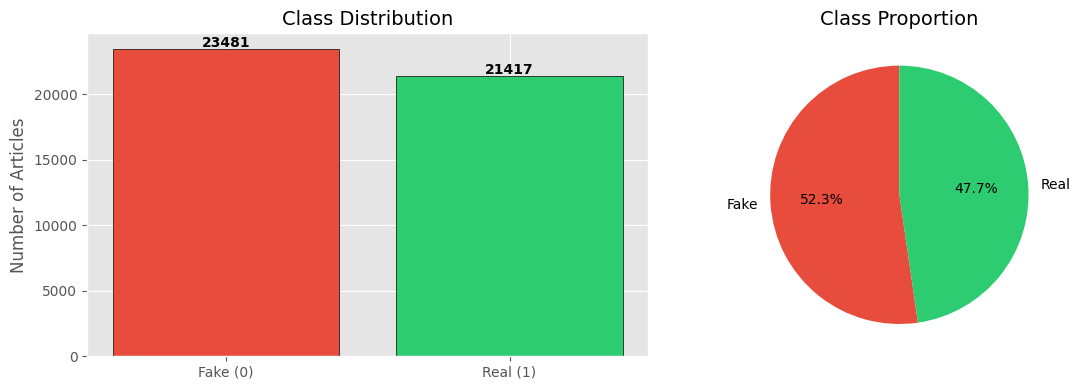

In [4]:
# 4. Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['label'].value_counts()
axes[0].bar(['Fake (0)', 'Real (1)'], counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14)
axes[0].set_ylabel('Number of Articles')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Fake', 'Real'], autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Class Proportion', fontsize=14)

plt.tight_layout()
plt.savefig('../data/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

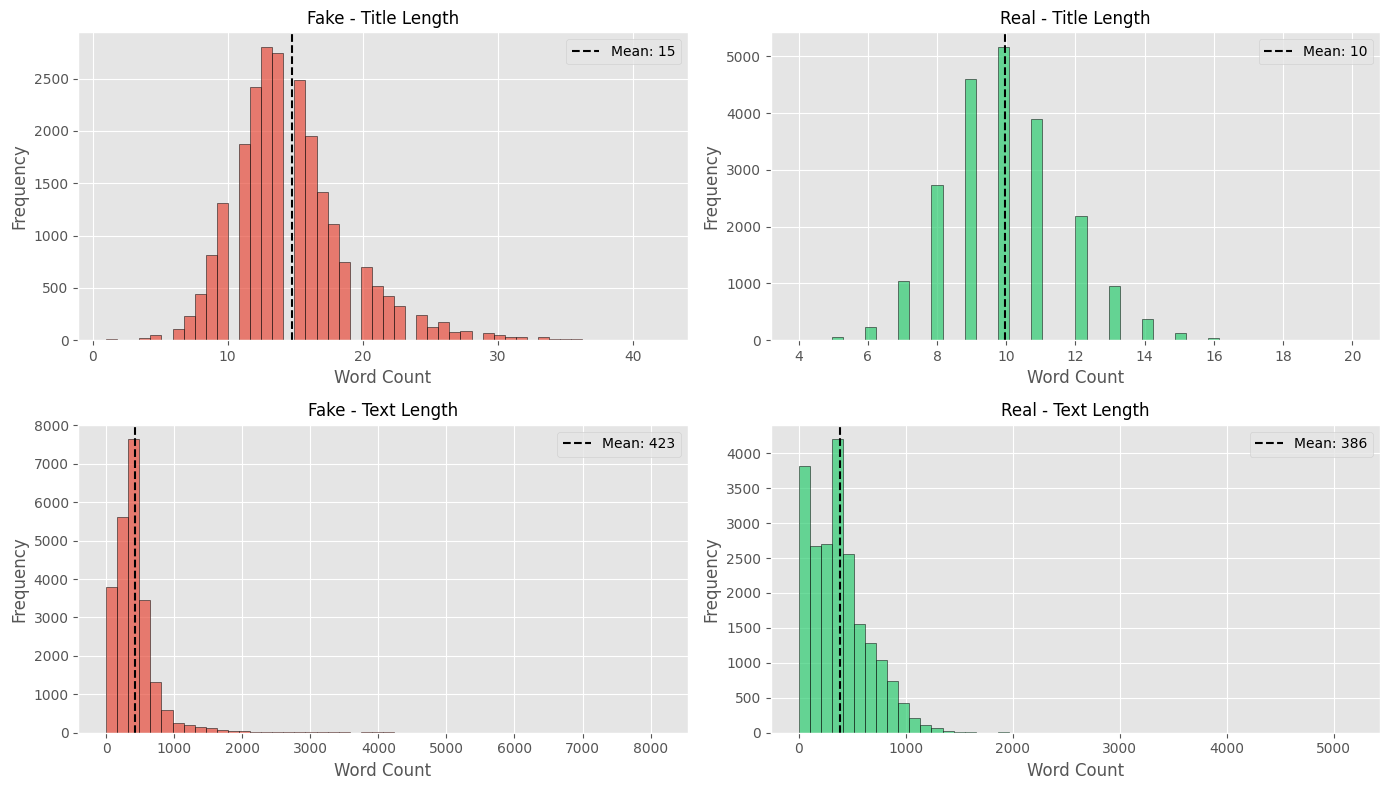


Text Length Stats by Class:
      title_len                                         text_len         \
          count  mean  std  min   25%   50%   75%   max    count   mean   
label                                                                     
0       23481.0  14.7  4.3  1.0  12.0  14.0  17.0  42.0  23481.0  423.2   
1       21417.0  10.0  1.7  4.0   9.0  10.0  11.0  20.0  21417.0  385.6   

                                                
         std  min    25%    50%    75%     max  
label                                           
0      408.4  0.0  240.0  363.0  506.0  8135.0  
1      274.0  0.0  148.0  359.0  525.0  5172.0  


In [5]:
# 5. Text Length Analysis
df['title_len'] = df['title'].apply(lambda x: len(str(x).split()))
df['text_len']  = df['text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, (col, label_val, color, name) in enumerate([
    ('title_len', 0, '#e74c3c', 'Fake - Title Length'),
    ('title_len', 1, '#2ecc71', 'Real - Title Length'),
    ('text_len',  0, '#e74c3c', 'Fake - Text Length'),
    ('text_len',  1, '#2ecc71', 'Real - Text Length'),
]):
    row, col_idx = divmod(i, 2)
    data = df[df.label == label_val][col]
    axes[row][col_idx].hist(data, bins=50, color=color, edgecolor='black', alpha=0.7)
    axes[row][col_idx].set_title(name, fontsize=12)
    axes[row][col_idx].set_xlabel('Word Count')
    axes[row][col_idx].set_ylabel('Frequency')
    axes[row][col_idx].axvline(data.mean(), color='black', linestyle='--', label=f'Mean: {data.mean():.0f}')
    axes[row][col_idx].legend()

plt.tight_layout()
plt.savefig('../data/text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nText Length Stats by Class:')
print(df.groupby('label')[['title_len','text_len']].describe().round(1))

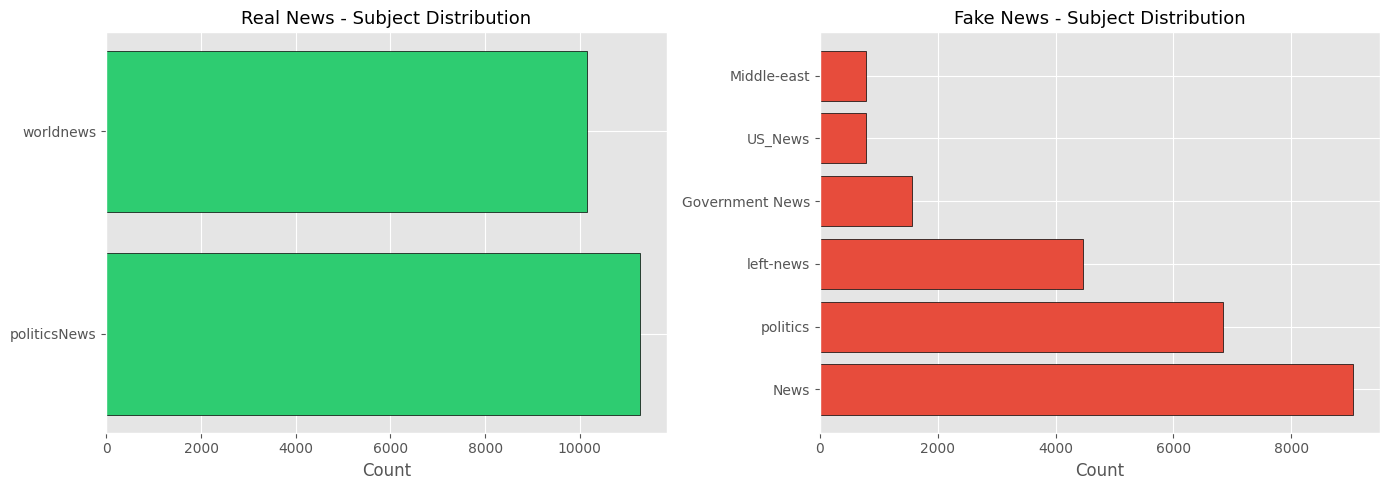

In [6]:
# 6. Subject / Category Distribution
if 'subject' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, label_val, title, color in [
        (axes[0], 1, 'Real News - Subject Distribution', '#2ecc71'),
        (axes[1], 0, 'Fake News - Subject Distribution', '#e74c3c')
    ]:
        counts = df[df.label==label_val]['subject'].value_counts().head(10)
        ax.barh(counts.index, counts.values, color=color, edgecolor='black')
        ax.set_title(title, fontsize=13)
        ax.set_xlabel('Count')
    plt.tight_layout()
    plt.savefig('../data/subject_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

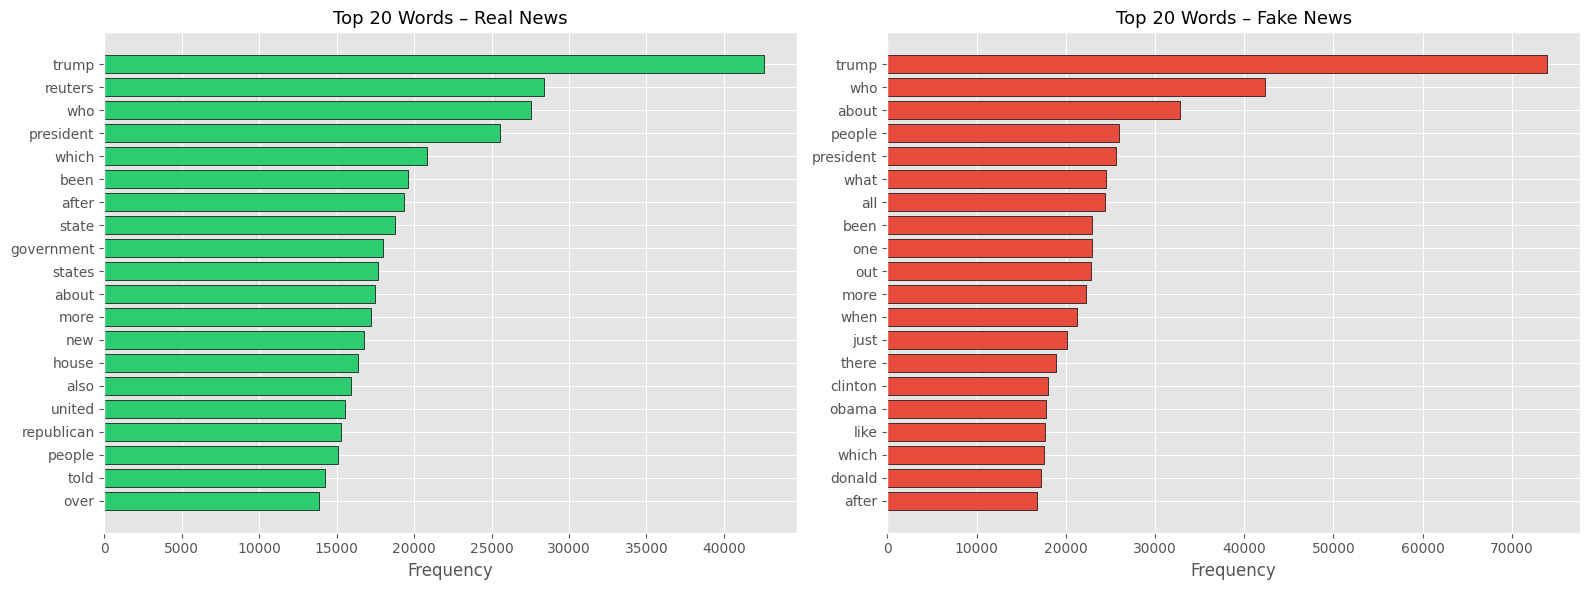

In [7]:
# 7. Most Common Words (simple)
from collections import Counter

stopwords = {'the','a','an','is','are','was','were','in','on','at','to','of',
             'and','or','it','this','that','for','with','as','be','by','from',
             'has','have','had','but','not','its','his','her','they','we','you',
             'he','she','their','our','said','will','would','can','could','may'}

def top_words(texts, n=20):
    words = ' '.join(texts).lower().split()
    words = [re.sub(r'[^a-z]', '', w) for w in words]
    words = [w for w in words if w and w not in stopwords and len(w) > 2]
    return Counter(words).most_common(n)

real_words = top_words(df[df.label==1]['text'].dropna())
fake_words = top_words(df[df.label==0]['text'].dropna())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, words, title, color in [
    (axes[0], real_words, 'Top 20 Words – Real News', '#2ecc71'),
    (axes[1], fake_words, 'Top 20 Words – Fake News', '#e74c3c')
]:
    labels, values = zip(*words)
    ax.barh(list(reversed(labels)), list(reversed(values)), color=color, edgecolor='black')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('../data/top_words.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# 8. Save processed dataframe for Week 2
df.to_csv('../data/raw_data.csv', index=False)
print('Data saved to ../data/raw_data.csv ✅')
print('\n=== EDA Summary ===')
print(f'Total articles : {len(df):,}')
print(f'Real news      : {df.label.sum():,} ({df.label.mean()*100:.1f}%)')
print(f'Fake news      : {(df.label==0).sum():,} ({(1-df.label.mean())*100:.1f}%)')
print(f'Avg text length: {df.text_len.mean():.0f} words')
print('Dataset is well-balanced – no resampling needed')

Data saved to ../data/raw_data.csv ✅

=== EDA Summary ===
Total articles : 44,898
Real news      : 21,417 (47.7%)
Fake news      : 23,481 (52.3%)
Avg text length: 405 words
Dataset is well-balanced – no resampling needed
